In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

# Create project folders
folders = ['data', 'notebooks', 'src', 'models', 'reports/figures']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully")
!ls


Folders created successfully
data  LICENSE  models  notebooks  README.md  reports  src


In [31]:
import pandas as pd

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)
df.to_csv('data/heart.csv', index=False)
print("Dataset downloaded successfully")
print(f"Shape: {df.shape}")
df.head()


Dataset downloaded successfully
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Imports & Setup**

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/heart.csv')
print(" Libraries loaded and data ready")


 Libraries loaded and data ready


**Dataset Overview**

In [20]:
print("SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
print("\nDATA TYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nDUPLICATED ROWS:", df.duplicated().sum())
df.describe().round(2)


SHAPE: (303, 14)

COLUMNS: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

DATA TYPES:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

MISSING VALUES:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

DUPLICATED ROWS: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


**Target Distribution**

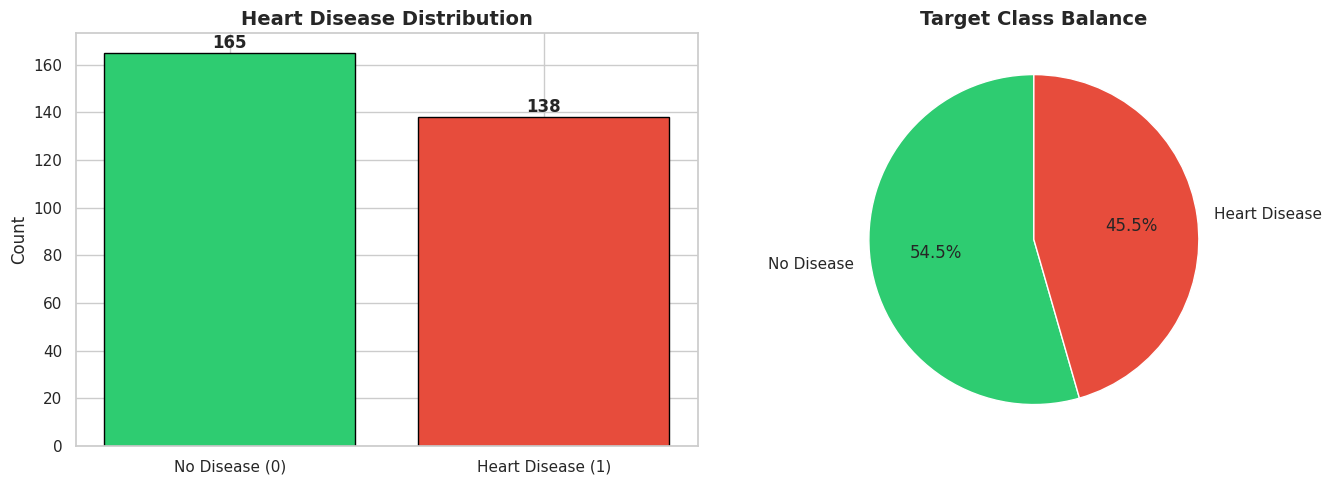

Plot saved


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax1 = axes[0]
target_counts = df['target'].value_counts()
ax1.bar(['No Disease (0)', 'Heart Disease (1)'],
        target_counts.values,
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black')
ax1.set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=['No Disease', 'Heart Disease'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Target Class Balance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")


**Age & Key Features Distribution**

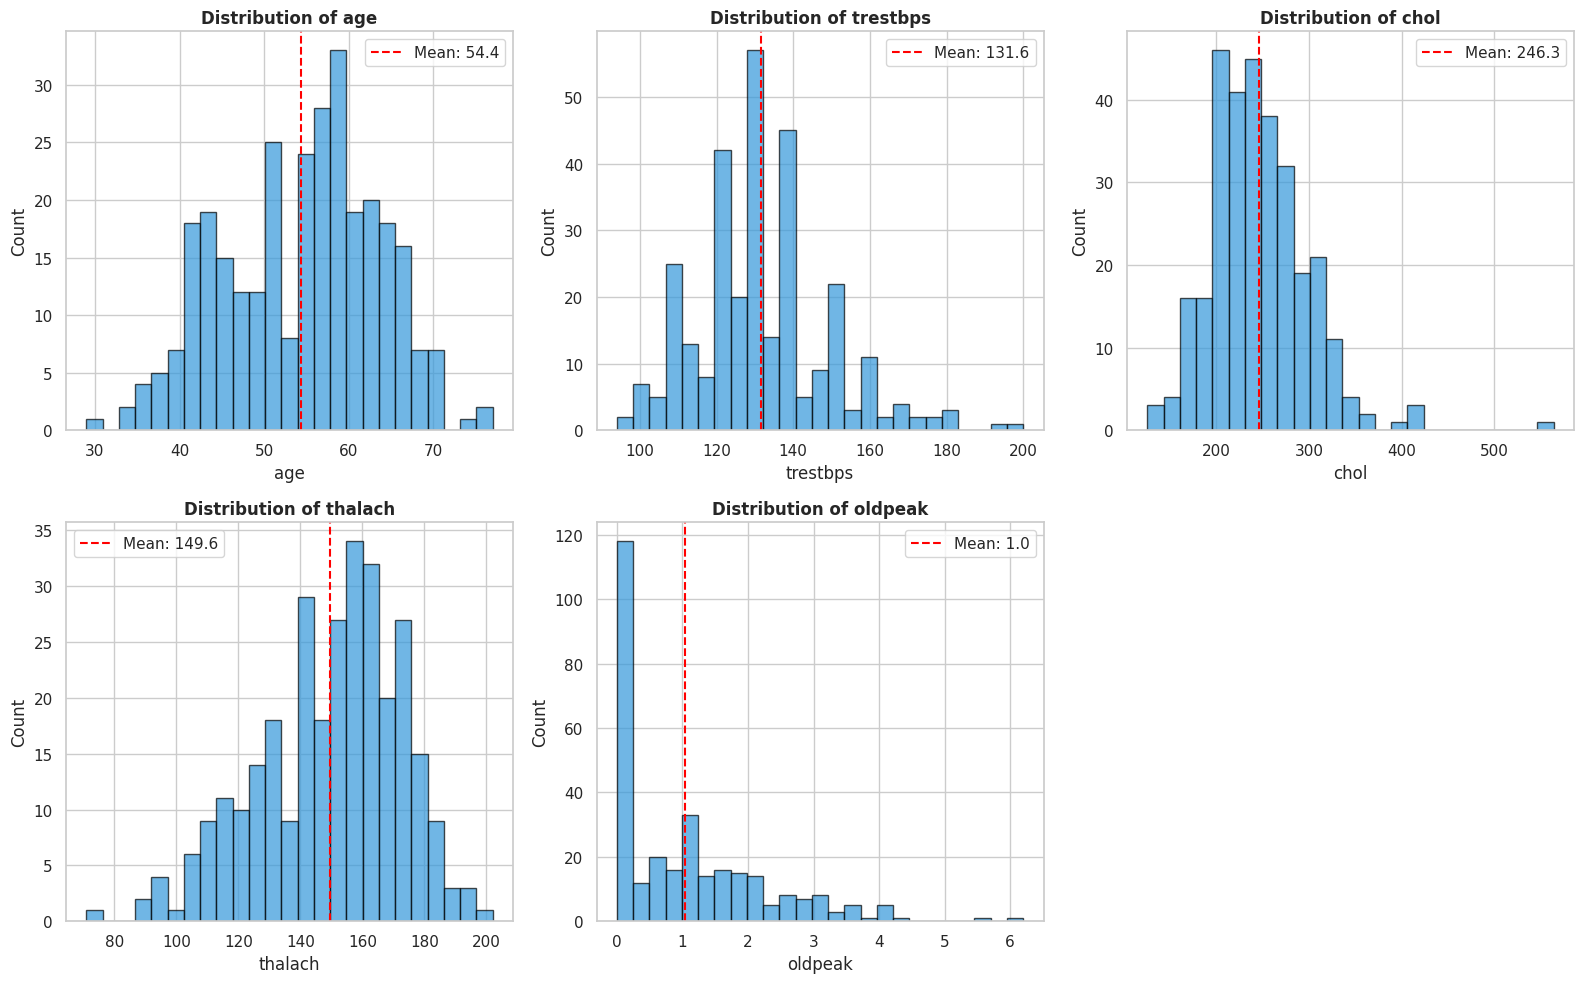

In [22]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=25, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


**Feature vs Target Analysis**

/tmp/ipykernel_5898/7322550.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df,
/tmp/ipykernel_5898/7322550.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df,
/tmp/ipykernel_5898/7322550.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df,
/tmp/ipykernel_5898/7322550.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

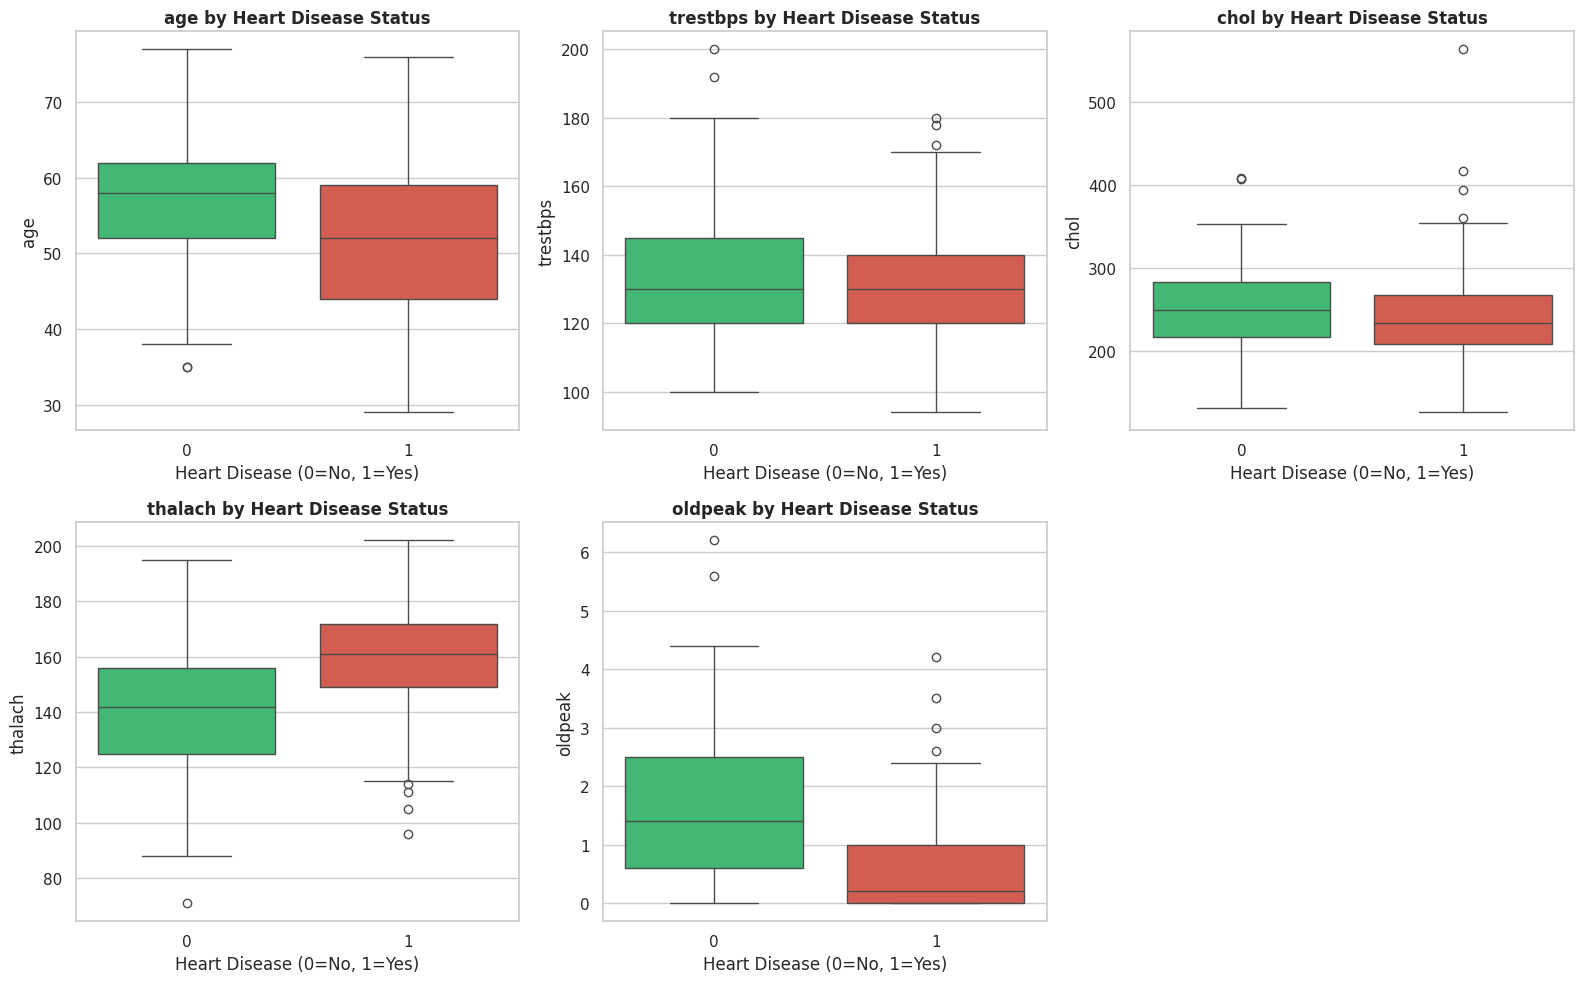

Plot saved


In [32]:
df['target'] = df['target'].astype(int)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='target', y=col, data=df,
                palette=['#2ecc71', '#e74c3c'],
                ax=axes[i])
    axes[i].set_title(f'{col} by Heart Disease Status', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Heart Disease (0=No, 1=Yes)')

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")


**Correlation Heatmap**

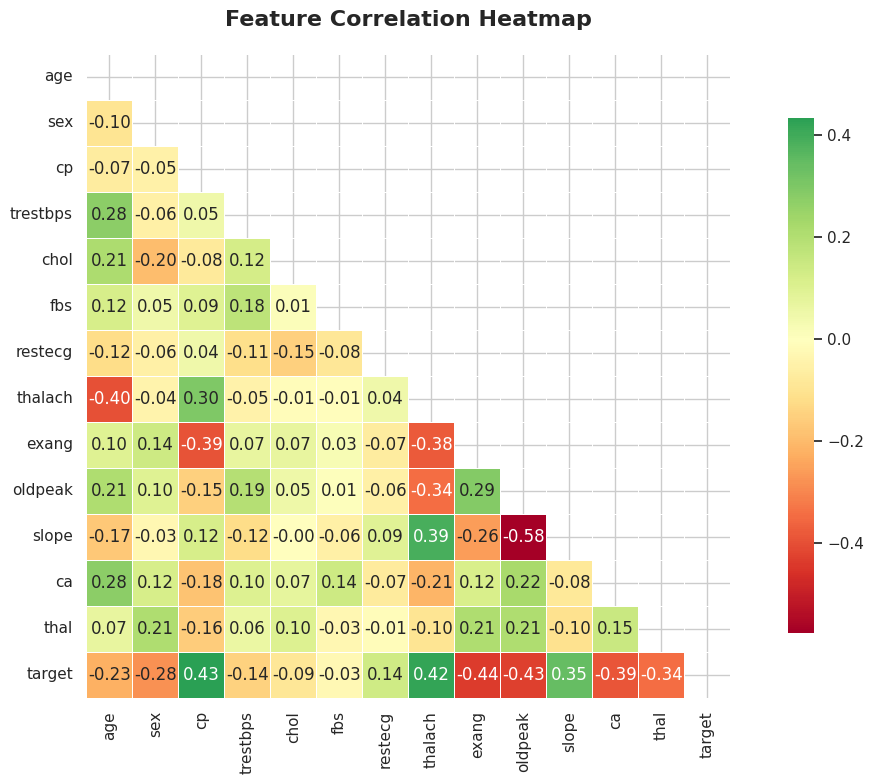

In [27]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Categorical Features Analysis**

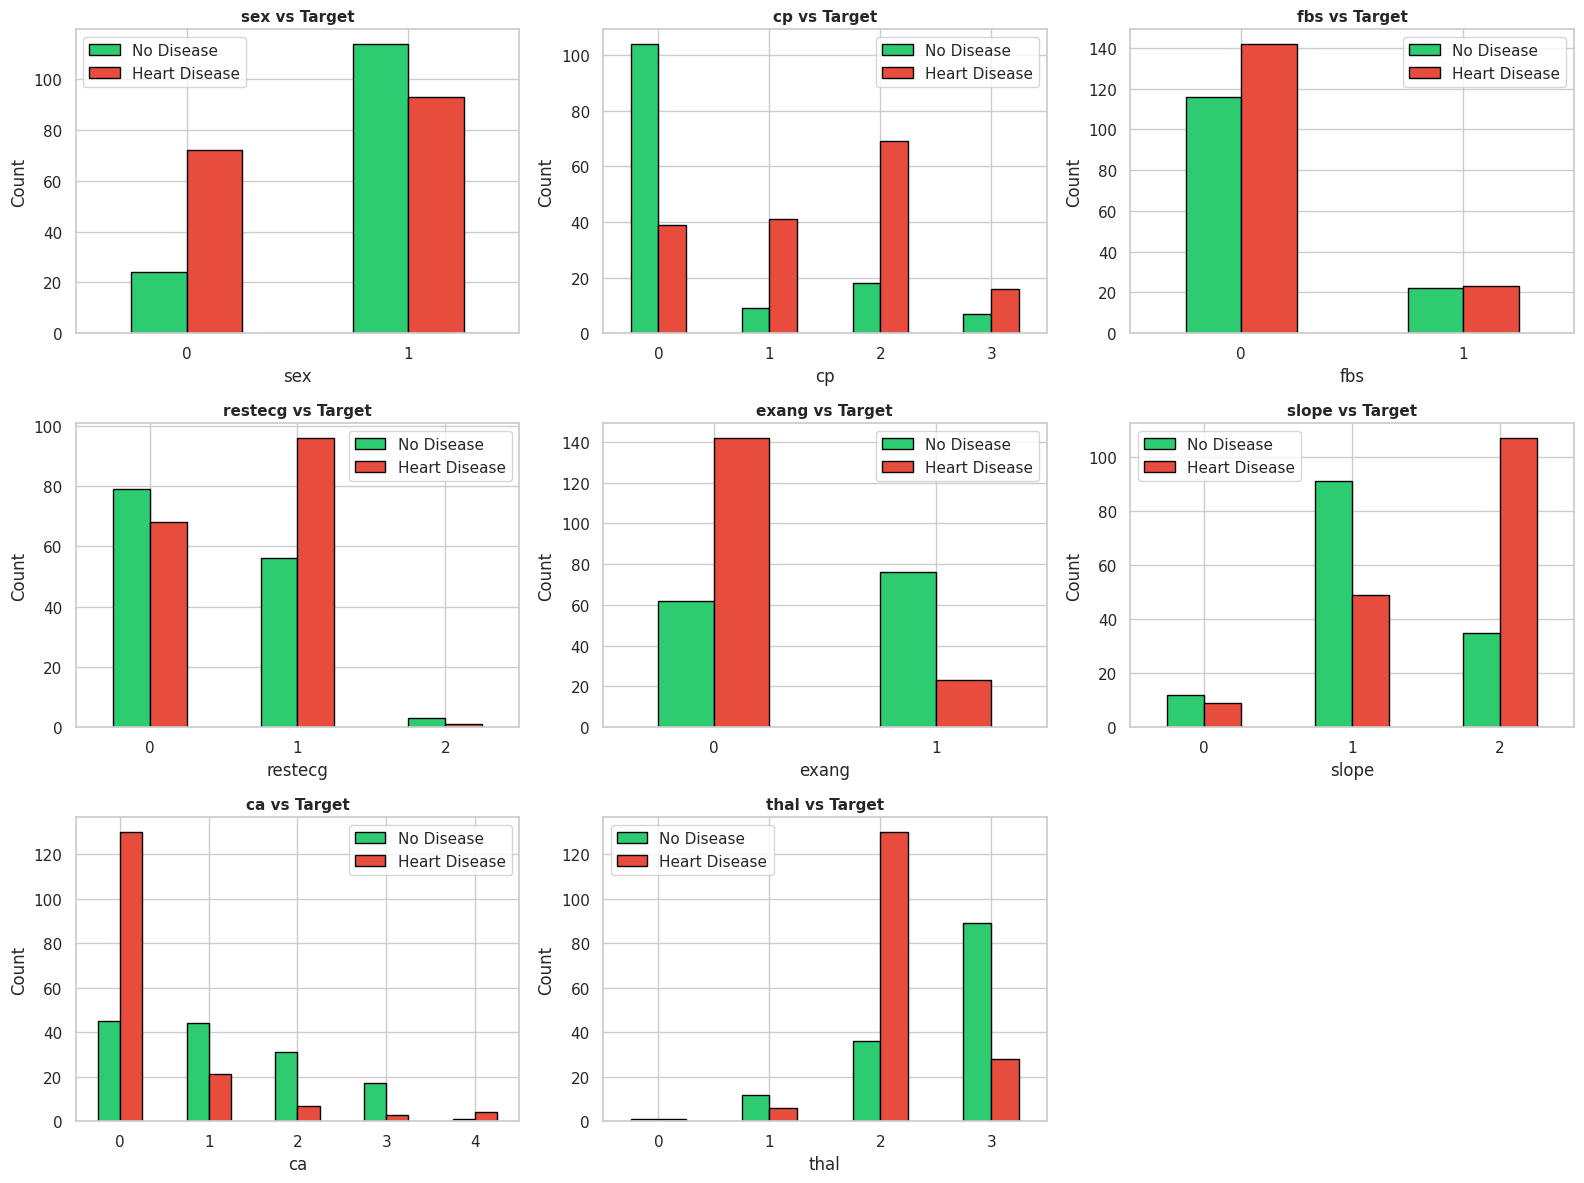

Plot saved


In [28]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar',
            ax=axes[i],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black',
            rot=0)
    axes[i].set_title(f'{col} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease', 'Heart Disease'])

axes[8].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")


**Key EDA Insights Summary**

In [29]:
print("=" * 60)
print("KEY EDA INSIGHTS")
print("=" * 60)

print(f"\n1. DATASET: {df.shape[0]} patients, {df.shape[1]-1} features, 1 target")
print(f"\n2. CLASS BALANCE:")
print(f"   - Heart Disease: {(df['target']==1).sum()} ({(df['target']==1).mean()*100:.1f}%)")
print(f"   - No Disease:    {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")

print(f"\n3. MISSING VALUES: {df.isnull().sum().sum()} total")

print(f"\n4. AGE RANGE: {df['age'].min()} - {df['age'].max()} years")
print(f"   Average age with disease: {df[df['target']==1]['age'].mean():.1f}")
print(f"   Average age without:      {df[df['target']==0]['age'].mean():.1f}")

print(f"\n5. TOP CORRELATED FEATURES WITH TARGET:")
corr_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in corr_target.head(5).items():
    print(f"   {feat}: {val:.3f}")


KEY EDA INSIGHTS

1. DATASET: 303 patients, 13 features, 1 target

2. CLASS BALANCE:
   - Heart Disease: 165 (54.5%)
   - No Disease:    138 (45.5%)

3. MISSING VALUES: 0 total

4. AGE RANGE: 29 - 77 years
   Average age with disease: 52.5
   Average age without:      56.6

5. TOP CORRELATED FEATURES WITH TARGET:
   exang: 0.437
   cp: 0.434
   oldpeak: 0.431
   thalach: 0.422
   ca: 0.392
